In [1]:
import firedrake
import numpy as np
import pickle as pkl
from numpy import pi as π
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from firedrake import *
from firedrake import Constant, inner, sqrt, tr, grad, div, as_vector, exp,sym, as_vector, dx, ds, Mesh, Function, project, TransferManager, RectangleMesh, ExtrudedMesh, FunctionSpace, Function, SpatialCoordinate, FiniteElement
import meshpy, meshpy.geometry, meshpy.triangle
import irksome
from irksome import Dt
from scipy.signal import detrend
import copy
import matplotlib
import irksome
from irksome import Dt
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import pickle as pkl
import tqdm
import emcee
import corner
import itertools
import xarray
import dtscalibration
import glob
from rasterio.plot import show
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import os
import sys
from pyproj import Transformer
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from scripts.AH_temp_funcs import *

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import shapefile as sf

import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask

import irksome
from irksome import Dt



%matplotlib widget

# 1. Load the necessary data

### 1.1 Borehole locations

In [2]:
### Load boreholes
borehole_locations = pd.read_csv('Borehole_Locations/Borehole_locations_DTS.csv')
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)
transformed_x, transformed_y = transformer.transform(borehole_locations['E'], borehole_locations['S'])

### 1.2 Fine mesh

In [3]:
upscale_factor_fine = 1/12
src_bed_fine = rasterio.open("Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_bed.tif")
src_surf_fine = rasterio.open("Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_surf.tif")
src_bed = src_bed_fine
src_surf = src_surf_fine

bed_DEM = src_bed.read(1,
                        out_shape=(
                            src_bed.count,
                            int(src_bed.height * upscale_factor_fine),
                            int(src_bed.width * upscale_factor_fine)
                        ),
                        resampling=Resampling.bilinear
                    )

# scale image transform
src_bed_transform = src_bed.transform * src_bed.transform.scale(
    (src_bed.width / bed_DEM.shape[-1]),
    (src_bed.height / bed_DEM.shape[-2])
)

surf_DEM = src_surf.read(1,
                        out_shape=(
                            src_surf.count,
                            int(src_surf.height * upscale_factor_fine),
                            int(src_surf.width * upscale_factor_fine)
                        ),
                        resampling=Resampling.bilinear
                    )

# scale image transform
src_surf_transform = src_surf.transform * src_surf.transform.scale(
    (src_surf.width / surf_DEM.shape[-1]),
    (src_surf.height / surf_DEM.shape[-2])
)

### Check if the bed DEMs is higher than the surface DEM (thickness is negative) ###


thickness = surf_DEM - bed_DEM
thickness[thickness > 0] = 0  # if positive, set to 0. This will mask the negative thickness values
zero_offset = copy.deepcopy(thickness)
zero_offset[zero_offset < 0 ] = -1 # this mask will lower the bed a further 1m in the areas where thickness is negative so the model doesn't crash on a zero.
bed_DEM = bed_DEM + thickness + zero_offset # add the negative values to the bed to push it lower to match the surface DEM

height = surf_DEM.shape[0]
width = surf_DEM.shape[1]
cols, rows = np.meshgrid(np.arange(width), np.arange(height))
xs, ys = rasterio.transform.xy(src_surf_transform, rows, cols)
lons= np.array(xs)
lats = np.array(ys)

surf_elevs = surf_DEM.flatten()
bed_elevs = bed_DEM.flatten()

"""
Create a unite fine mesh to interpolate the coarse model results onto.
"""

layers = 5 # number of layers in z direction of the extruded mesh
nx = width - 1
ny = height - 1

Lx = lons.max() # x extent, get this from the DEM
Ly = lats.max() # y extent, get this from the DEM

origin_x = lons.min() # origin (lower left corner) in x, get this from the DEM
origin_y = lats.min() # origin (lower left corner) in y, get this from the DEM

base_mesh = RectangleMesh(nx,ny, Lx, Ly, originX=origin_x, originY=origin_y)

unit_extruded_mesh = ExtrudedMesh(base_mesh, layers=layers)

xi = base_mesh.coordinates.dat.data_ro[:,:2] # Get the mesh coordinates from the base mesh

base_fs = FunctionSpace(base_mesh, "CG", 1)

x,y, = SpatialCoordinate(base_mesh)

# You could set this field any way you like.
## Bed and surface DEM resolution should be nx+1, ny+1 as to match the coordinates of the mesh.

# Now we transfer the bathymetry field into a depth-averaged field.
extruded_element = FiniteElement("R", "interval", 0)
extruded_space = FunctionSpace(unit_extruded_mesh,
                                TensorProductElement(base_fs.ufl_element(),
                                                    extruded_element))


from scipy.interpolate import griddata
## interpolate the DEMs to the mesh coordinates so it is given in the mesh coordinate order
points = np.array([xs,ys]).T # DEM pixel coordinates
xi = base_mesh.coordinates.dat.data_ro[:,:2] # Get the mesh coordinates from the base mesh
surf_interp = griddata(points, surf_DEM.flatten(), xi, method='nearest', fill_value=np.nan, rescale=False)
bed_interp = griddata(points, bed_DEM.flatten(), xi, method='nearest', fill_value=np.nan, rescale=False)

## Extrude the bed and surface
extruded_bed = Function(extruded_space)
extruded_bed.dat.data_wo[:] = bed_interp

extruded_surface = Function(extruded_space)
extruded_surface.dat.data_wo[:] = surf_interp

# Build a new coordinate field by change of coordinates.
x, y, z = SpatialCoordinate(unit_extruded_mesh)
new_coordinates = assemble(
    interpolate(
        as_vector([x, y, (1-z) * extruded_bed + z * extruded_surface]),
        unit_extruded_mesh.coordinates.function_space()
    )
)


# Finally build the mesh you are actually after.
mesh_fine = Mesh(new_coordinates) # Mesh(new_coordinates, tolerance=50)
x_fine, y_fine, z_fine = SpatialCoordinate(mesh_fine)

/opt/firedrake/firedrake/interpolation.py:391: FutureWarning: The use of `interpolate` to perform the numerical interpolation is deprecated.
This feature will be removed very shortly.

Instead, import `interpolate` from the `firedrake.__future__` module to update
the interpolation's behaviour to return the symbolic `ufl.Interpolate` object associated
with this interpolation.

You can then assemble the resulting object to get the interpolated quantity
of interest. For example,

```
from firedrake.__future__ import interpolate
...

assemble(interpolate(expr, V))
```

Alternatively, you can also perform other symbolic operations on the interpolation operator, such as taking
the derivative, and then assemble the resulting form.

  warnings.warn("""The use of `interpolate` to perform the numerical interpolation is deprecated.


### 1.3 Load the flowfield

In [4]:
pressure_space = firedrake.FunctionSpace(mesh_fine, "CG", 1)
velocity_space = firedrake.VectorFunctionSpace(mesh_fine, "CG", 3)
Y = velocity_space * pressure_space
flow = firedrake.Function(Y)


chk = DumbCheckpoint("Saved_Models/fine_mesh_flow_96m_updated_viscosity", mode=FILE_READ)
chk.load(flow, name="fine_mesh_flow")

u,p = firedrake.split(flow)

/opt/firedrake/firedrake/checkpointing.py:103: DeprecationWarning: DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.",


### 1.4 Load the temperature field

In [5]:
V = firedrake.FunctionSpace(mesh_fine, "CG", 1)

T = firedrake.Function(V)

chk = DumbCheckpoint("Saved_Models/fine_mesh_temperature_96m_updated_viscosity", mode=FILE_READ)
chk.load(T, name="fine_mesh_temp")

/opt/firedrake/firedrake/checkpointing.py:103: DeprecationWarning: DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.",


# 2. Make the temperature time stepping

In [6]:
δx = mesh_fine.cell_sizes.dat.data_ro[:].min()
umax = flow.sub(0).dat.data_ro[:].max()
δt = Constant(spy/.1)

In [7]:
from ufl import Measure
dx = ufl.Measure("dx", domain=mesh_fine)


ϕ = firedrake.TestFunction(V)

geo_flux = 0.05 # W/m^2 
k = Constant(2.22)  # W / m C

geothermal_flux = -geo_flux*ϕ  * ds_b
F_diffusion = k*inner(grad(T), grad(ϕ)) * dx
F_advection = - ρ * c * T * inner(u, grad(ϕ)) * dx

F = ρ * c * Dt(T) * ϕ * dx + F_diffusion + F_advection + geothermal_flux

In [8]:
T_mean = Constant(-32.9999) #average temp (C)
T_Mean = -33 #average temp (C)

temperature_expr = T_mean - (z_fine - 2000)*.01

surface_temp_bc = firedrake.DirichletBC(V, temperature_expr, 'top')

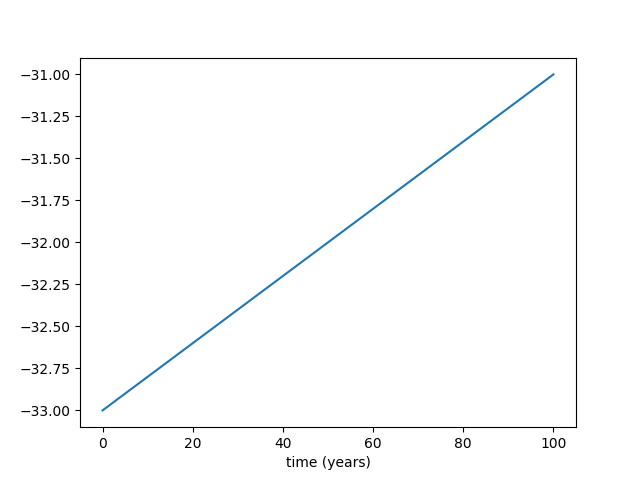

In [9]:
δT = 25.0
θ = 1 * π / 2
year = spy
years = 100
final_time = years * spy # years modeling * spy

freq = 1 # 1 for annual cycle
num_steps = int(final_time / float(δt))

# def surface_temperature(t):
#     return T_Mean + δT * np.sin(2 * π *freq* t / year + θ) + (t/final_time)*1

def surface_temperature(t):
    return T_Mean + (t/final_time)*2

ts = np.linspace(0.0, final_time, num_steps + 1)

surface_temps = surface_temperature(ts)

fig, ax = plt.subplots()
ax.set_xlabel("time (years)")
#ax.set_ylabel("temperature (${}^\circ$C)")
ax.plot(ts / spy, surface_temps);

In [10]:
method = irksome.BackwardEuler()
temperature_solver = irksome.TimeStepper(F, method, Constant(0.0), δt, T, bcs=surface_temp_bc)

In [11]:
import tqdm
final_time = years* spy 
num_steps = int(final_time / float(δt))
Ts = [T.copy(deepcopy=True)]

for step in tqdm.trange(num_steps):
    t = ts[step]
    T_mean.assign(surface_temperature(t))

    temperature_solver.advance()


    Ts.append(T.copy(deepcopy=True))


100%|██████████| 10/10 [00:05<00:00,  1.91it/s]


# 3. Plot the temperatures

In [12]:
z_vals = mesh_fine.coordinates.dat.data_ro[:,2]
depth_values = np.arange(z_vals.min(), z_vals.max(), 5)

temp_dict_climate = {}

for x_bore, y_bore, name_bore in zip(transformed_x, transformed_y, borehole_locations['Core']):
    temp_coords = []
    temp_vals = []
    for z_bore in depth_values:
        try:
            temp = Ts[-1].at(x_bore, y_bore, z_bore)
            temp_coords.append([x_bore, y_bore, z_bore])
            temp_vals.append(temp)
        except:
            continue
    if len(temp_vals) > 0:
        temp_dict_climate[name_bore] = [np.array(temp_vals), np.array(temp_coords)]


In [43]:
avg_temps = pd.read_pickle('Borehole_Temps/avg_temps.pkl')
residual_temps = pd.read_pickle('Borehole_Temps/residual_temps.pkl')

boreholes = ['ALHIC1901', 'ALHIC1902', 'ALHIC1903', 'ALHIC2201', 'ALHIC2301', 'ALHIC2302', 'ALHIC2401']

# for i in avg_temps:
#     print(avg_temps[i][0].values[0])
#     print(i)

core_surface_z = {'ALHIC1901': 1937.88,
                  'ALHIC1902': 1940.76, 
                  'ALHIC1903': 1884.84,
                  'ALHIC2201': 1934.54,
                  'ALHIC2301': 1865.68, 
                  'ALHIC2302': 1940.76, 
                  'ALHIC2401': 1865.68}

/tmp/ipykernel_1667223/2989260921.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


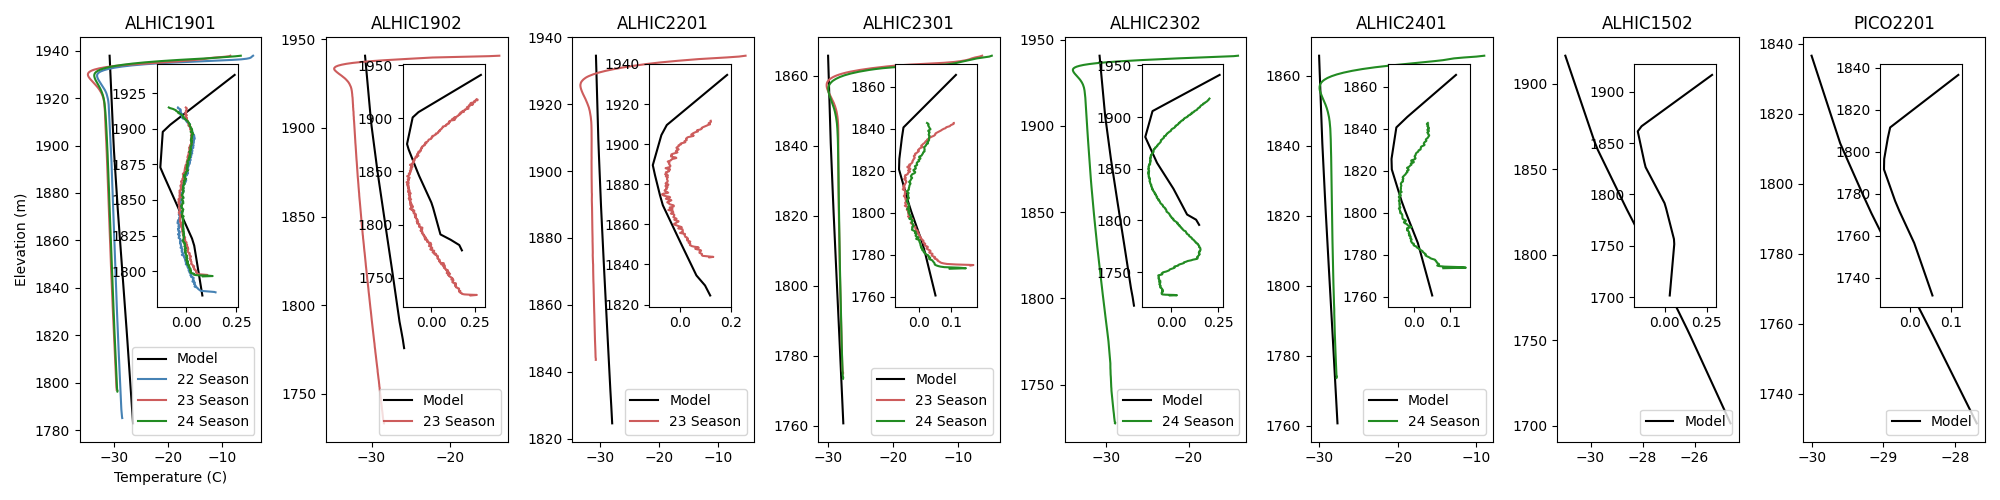

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [59]:
fig,axes = plt.subplots(1, len(temp_dict_climate), figsize=[20,5])

for name, ax in zip(temp_dict_climate, axes):
    try:

        z_offset = temp_dict_climate[name][1][:,2][-1] - core_surface_z[name]
        ax.plot(temp_dict_climate[name][0], temp_dict_climate[name][1][:,2] - z_offset, c='black', label='Model')


        axinses = inset_axes(ax, width = "100%", height = "100%", loc='lower right', bbox_to_anchor=(.5, .30, .45, .60), bbox_transform=ax.transAxes, borderpad=1)
        axinses.plot(scipy.signal.detrend(temp_dict_climate[name][0]), temp_dict_climate[name][1][:,2]-z_offset, c='black')
    except:
        ax.plot(temp_dict_climate[name][0], temp_dict_climate[name][1][:,2] - 40, c='black', label='Model')


        axinses = inset_axes(ax, width = "100%", height = "100%", loc='lower right', bbox_to_anchor=(.5, .30, .45, .60), bbox_transform=ax.transAxes, borderpad=1)
        axinses.plot(scipy.signal.detrend(temp_dict_climate[name][0]), temp_dict_climate[name][1][:,2]-40, c='black')
    
    ax.set_title(name)

    for i in avg_temps:
        if i.startswith(name):
            if i[-2:] == '22':
                color = 'steelblue'
            elif i[-2:] == '23':
                color = 'indianred'
            elif i[-2:] == '24':
                color = 'forestgreen'
            ax.plot(avg_temps[i][2], avg_temps[i][0], label=i[-2:]+' Season',c=color)
            axinses.plot(residual_temps[i][2], residual_temps[i][0], label=i[-2:]+' Season',c=color)
    ax.legend(loc='lower right')


axes[0].set_ylabel('Elevation (m)')
axes[0].set_xlabel('Temperature (C)')

plt.tight_layout()
plt.show()

plt.savefig('Figures/fig2.eps', dpi=300, bbox_inches='tight', format='eps', transparent=True)
plt.savefig('Figures/fig2.png', dpi=300, bbox_inches='tight', format='png', transparent=True)

#### Temperature from a fast flow region

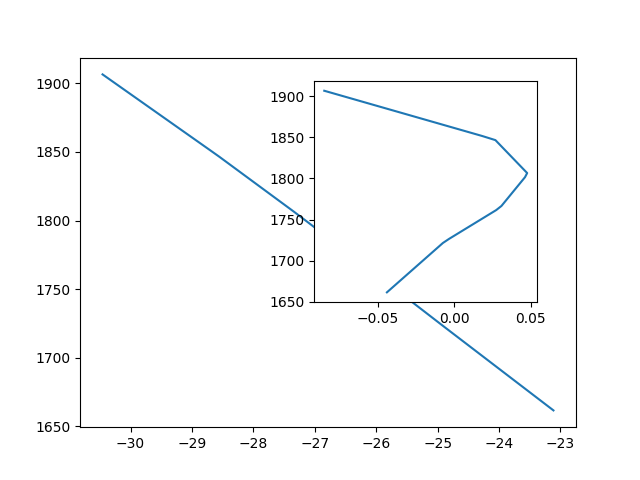

In [190]:
temp_fast_temps = []
temp_fast_depths = []
for z_bore in depth_values:
    try:
        temp_fast = Ts[0].at(510000, -1.3559e6, z_bore)
        temp_fast_temps.append(temp_fast)
        temp_fast_depths.append(z_bore)
    except:
        continue

fig,ax = plt.subplots()

ax.plot(temp_fast_temps, temp_fast_depths)

axinses = inset_axes(ax, width = "100%", height = "100%", loc='lower right', bbox_to_anchor=(.5, .30, .45, .60), bbox_transform=ax.transAxes, borderpad=1)

axinses.plot(scipy.signal.detrend(temp_fast_temps), temp_fast_depths)

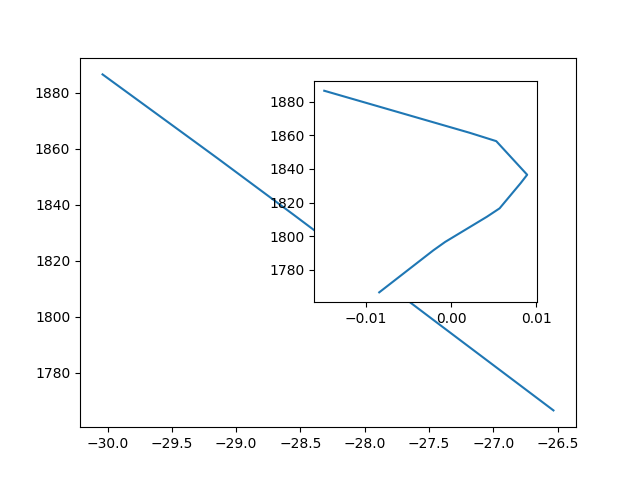

In [191]:
temp_fast_temps = []
temp_fast_depths = []
for z_bore in depth_values:
    try:
        temp_fast = Ts[0].at(508000, -1.3525e6, z_bore)
        temp_fast_temps.append(temp_fast)
        temp_fast_depths.append(z_bore)
    except:
        continue



fig,ax = plt.subplots()

ax.plot(temp_fast_temps, temp_fast_depths)

axinses = inset_axes(ax, width = "100%", height = "100%", loc='lower right', bbox_to_anchor=(.5, .30, .45, .60), bbox_transform=ax.transAxes, borderpad=1)

axinses.plot(scipy.signal.detrend(temp_fast_temps), temp_fast_depths)

# Notes 10/28

- Two rows of plots
    - top plots would be climate history with advection
    - bottom row would be no climate

- Include the fake borehole in line with the other

- Make an updated map view of the advection importance